# 1. Model Comparer

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter

import torch
from torchvision import transforms

#local imports
from galaxy_transforms import LuptonRgbTransform, ScaleToUnitIntervalTransform


from zoobot.pytorch.training.finetune import FinetuneableZoobotClassifier
from ring_detection_model import RingDetectionZoobot

# Multilabel class mapping
RING_CLASS_TO_MULTILABEL = {
    0: [0, 0],  # No rings
    1: [1, 0],  # Inner ring only
    2: [0, 1],  # Outer ring only
    3: [1, 1]   # Both rings
}

#Optimize PyTorch performance
RANDOM_SEED = 42

torch.set_float32_matmul_precision('high')
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [2]:
# Define the versions to compare
selected_version_a = 25 #29  # Change this to load a different lightning_logs/version_* checkpoint (baseline model)
selected_version_b = 31  # Change this to load a different lightning_logs/version_* checkpoint (new model)

name_a = f"version_{selected_version_a}"
name_b = f"version_{selected_version_b}"

In [3]:
# Set up paths
current_dir = os.getcwd()
path = os.path.join(current_dir)
data_path = os.path.join(path, 'Data')
model_path = os.path.join(path, 'Models')
os.makedirs(data_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

#set image_path to D:\ML Data\FitsGalaxies using os.path.join
image_path = os.path.join("D:\\", "ML Data", "FitsGalaxies")

HOME_PATH = path
DATA_PATH = data_path
MODEL_PATH = model_path
IMAGE_PATH = image_path

print(f"HOME_PATH: {HOME_PATH}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"IMAGE_PATH: {IMAGE_PATH}")

DATASET_CSV = 'dataset_all_with_files_patched.csv'

HOME_PATH: d:\ML Projects\RingMultilabelClassification
DATA_PATH: d:\ML Projects\RingMultilabelClassification\Data
MODEL_PATH: d:\ML Projects\RingMultilabelClassification\Models
IMAGE_PATH: D:\ML Data\FitsGalaxies


In [4]:
# Load dataset
df_dataset = pd.read_csv(os.path.join(DATA_PATH, DATASET_CSV))

print("Dataset Information:")
print(f"\nDataset shape: {df_dataset.shape}")
print(f"\nColumn names: {df_dataset.columns.tolist()}")
print(f"\nBasic Statistics:\n {df_dataset.describe()}")
print(f"\nFirst few rows:")
print(df_dataset.head())

# Check ring_class distribution
print(f"\n\nRing Class Distribution:")
ring_dist = df_dataset['ring_class'].value_counts().sort_index()
print(ring_dist)

print(f"\n\nMultilabel Distribution (inner_ring, outer_ring):")
if 'inner_ring' in df_dataset.columns and 'outer_ring' in df_dataset.columns:
    multilabel_dist = df_dataset.groupby(['inner_ring', 'outer_ring']).size()
    print(multilabel_dist)

Dataset Information:

Dataset shape: (8346, 15)

Column names: ['id_str', 'ra', 'dec', 'z', 'anillos', 'dataset', 'ring_class', 'ring_class_0', 'ring_class_1', 'ring_class_2', 'ring_class_3', 'inner_ring', 'outer_ring', 'file_loc', 'validation_status']

Basic Statistics:
                 ra          dec            z      anillos   ring_class  \
count  8346.000000  8346.000000  8346.000000  8346.000000  8346.000000   
mean    184.653690    25.366616     0.034619     1.529835     0.382459   
std      60.193130    18.306968     0.013316     3.144514     0.786128   
min       0.008759   -11.015802     0.007122     0.000000     0.000000   
25%     153.537672    10.777381     0.024547     0.000000     0.000000   
50%     187.332100    24.622751     0.032400     0.000000     0.000000   
75%     221.278928    39.432592     0.043344     0.000000     0.000000   
max     359.276680    70.133229     0.090440    12.000000     3.000000   

       ring_class_0  ring_class_1  ring_class_2  ring_class_

In [5]:
from datasets import ZoobotFitsDataModule

baseline_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    LuptonRgbTransform(stretch=0.5, Q=10),
    ScaleToUnitIntervalTransform(),
])

new_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    LuptonRgbTransform(stretch=0.5, Q=10),
    ScaleToUnitIntervalTransform(),
])

datamodule_a = ZoobotFitsDataModule(
    csv_path=os.path.join(DATA_PATH, "dataset_all_with_files_patched.csv"),
    img_dir=IMAGE_PATH,
    batch_size=64,
    num_workers=0,
    transform_pipeline=baseline_pipeline,
    use_augmentation=True
)
datamodule_a.setup()

datamodule_b = ZoobotFitsDataModule(
    csv_path=os.path.join(DATA_PATH, "dataset_all_with_files_patched.csv"),
    img_dir=IMAGE_PATH,
    batch_size=64,
    num_workers=0,
    transform_pipeline=new_pipeline,
    use_augmentation=True
)
datamodule_b.setup()

Training class distribution (ring_class → count): {0: 5061, 1: 1013, 2: 266, 3: 336}
Training class distribution (ring_class → count): {0: 5061, 1: 1013, 2: 266, 3: 336}


In [6]:
# Load a selected checkpoint version, tune thresholds on validation, and visualize test predictions.
import glob
from ring_detection_model import tune_thresholds_on_val


def load_model_from_version(
    selected_version,
    *,
    home_path,
    datamodule,
    encoder_dim=640,
    hidden_dim=256,
    dropout_rate=0.4,
    device=None,
    map_location='cpu',
):
    """Load a RingDetectionZoobot checkpoint by lightning log version and return the model."""
    # Recreate a compatible encoder for checkpoint loading
    temp_model = FinetuneableZoobotClassifier(
        name='hf_hub:mwalmsley/zoobot-encoder-convnext_nano',
        num_classes=2,
        label_col='ring_class'
    )
    encoder = temp_model.encoder

    checkpoint_pattern = os.path.join(
        home_path, "lightning_logs", "version_*", "checkpoints", "stage*-best-epoch=*.ckpt"
    )
    checkpoint_paths = glob.glob(checkpoint_pattern)

    if not checkpoint_paths:
        raise FileNotFoundError(f"No checkpoints found matching: {checkpoint_pattern}")

    available_versions = sorted(
        {
            int(os.path.normpath(ckpt).split(os.sep)[-3].replace("version_", ""))
            for ckpt in checkpoint_paths
        }
    )

    if selected_version not in available_versions:
        raise ValueError(
            f"Requested version_{selected_version} not found. Available versions: {available_versions}"
        )

    selected_ckpts = [
        ckpt
        for ckpt in checkpoint_paths
        if os.path.normpath(ckpt).split(os.sep)[-3] == f"version_{selected_version}"
    ]
    selected_ckpt = max(selected_ckpts, key=os.path.getmtime)
    # selected_ckpt = _patch_checkpoint_version_key(selected_ckpt, map_location=map_location)
    print(f"Using checkpoint: {selected_ckpt}")

    pos_weight = datamodule.get_pos_weight()
    model = RingDetectionZoobot.load_from_checkpoint(
        checkpoint_path=selected_ckpt,
        encoder=encoder,
        encoder_dim=encoder_dim,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
        pos_weight=pos_weight,
        map_location=map_location
    )
   
    if model.inner_ring_threshold != 0.5 and model.outer_ring_threshold != 0.5:
        best_t_inner = model.inner_ring_threshold
        best_t_outer = model.outer_ring_threshold
        print(f"Using stored thresholds from checkpoint -> inner: {best_t_inner:.3f}, outer: {best_t_outer:.3f}")
    else:
        best_t_inner, best_t_outer = tune_thresholds_on_val(
            model,
            datamodule.val_dataloader(),
            model.device,
            threshold_range=(0.25, 0.95),
            step=0.02,
            metric='f1',
        )
        model.inner_ring_threshold = best_t_inner
        model.outer_ring_threshold = best_t_outer
        print(f"Best thresholds -> inner: {best_t_inner:.3f}, outer: {best_t_outer:.3f}")

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    # Keep path accessible for later notebook cells if needed
    model.loaded_checkpoint_path = selected_ckpt
    
    model = model.to(device)
    return model

model_a = load_model_from_version(
    selected_version_a,
    home_path=HOME_PATH,
    datamodule=datamodule_a,
)

model_b = load_model_from_version(
    selected_version_b,
    home_path=HOME_PATH,
    datamodule=datamodule_b,
)

Using checkpoint: d:\ML Projects\RingMultilabelClassification\lightning_logs\version_25\checkpoints\stage2-best-epoch=1.ckpt
✓ Encoder frozen
Best thresholds -> inner: 0.590, outer: 0.730
Using checkpoint: d:\ML Projects\RingMultilabelClassification\lightning_logs\version_31\checkpoints\stage2-best-epoch=9.ckpt
✓ Encoder frozen
Best thresholds -> inner: 0.530, outer: 0.590


C:\Users\Francisco-PC\AppData\Local\Temp\ipykernel_3476\2048984558.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


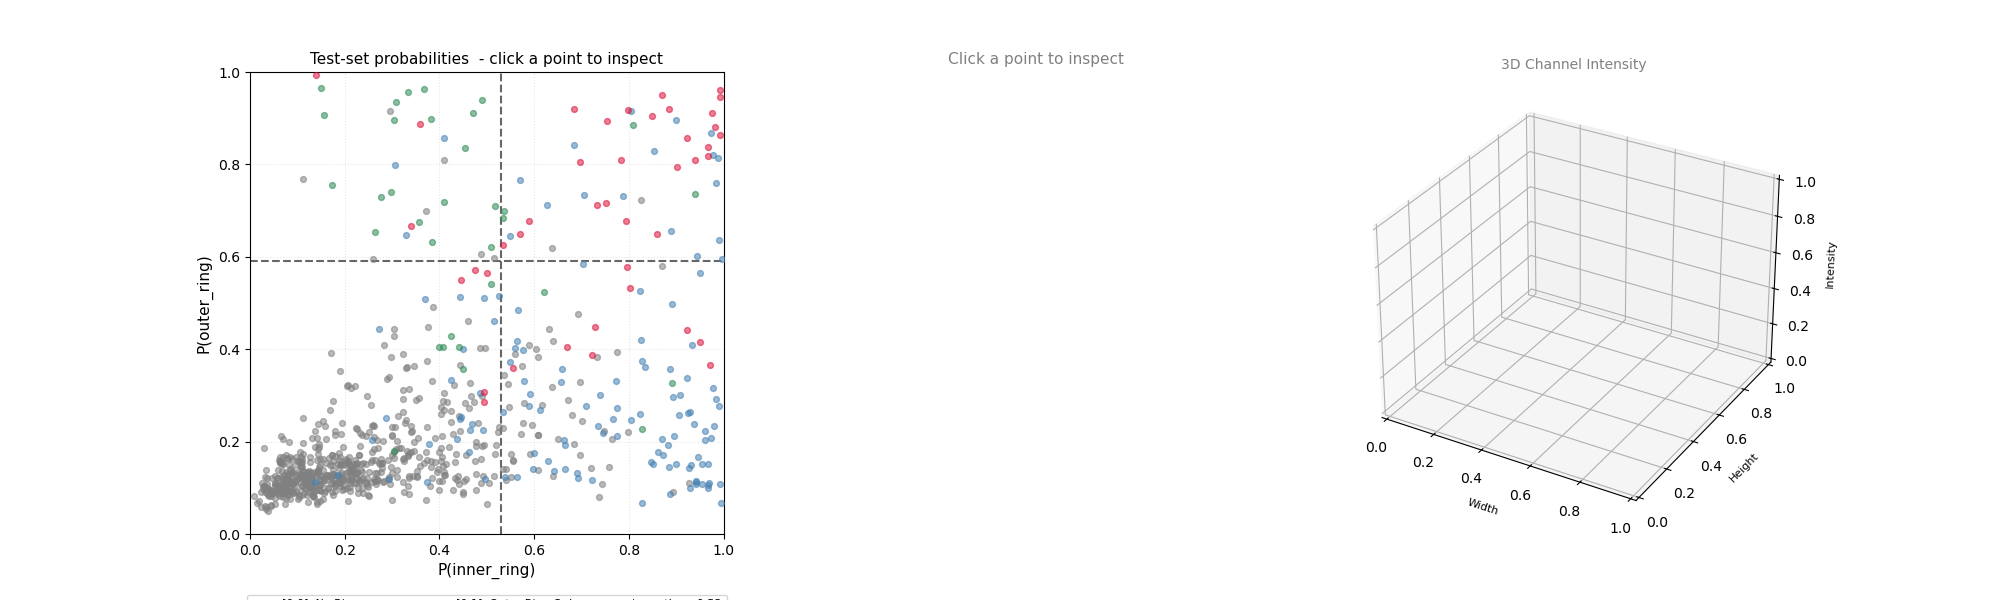

In [7]:
# 5.X Interactive probability explorer reusable for any loaded checkpoint
%matplotlib widget

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def plot_interactive_probability_explorer(
    model,
    dataloader,
    best_t_inner,
    best_t_outer,
    *,
    use_tta=True,
    n_rotations=4,
    flip=True,
    downsample_3d=1,
):
    """Interactive scatter + 2D image + 3D channels for multilabel predictions.

    Args:
        model: Trained multilabel model (e.g., RingDetectionZoobot loaded from checkpoint).
        dataloader: DataLoader yielding model batches.
        best_t_inner (float): Decision threshold for inner ring.
        best_t_outer (float): Decision threshold for outer ring.
        use_tta (bool): Use model.predict_proba_tta if available.
        n_rotations (int): TTA rotations when use_tta=True.
        flip (bool): TTA flip when use_tta=True.
        downsample_3d (int): Spatial step for 3D surfaces (1 = full resolution).

    Returns:
        tuple: (probs, labels, preds_bin, inputs)
    """
    model.eval()
    device = model.device

    all_probs = []
    all_labels = []
    all_inputs = []

    with torch.no_grad():
        for batch in dataloader:
            x, y = model.batch_to_supervised_tuple(batch)
            x = x.to(device)
            y = y.to(device)

            if use_tta and hasattr(model, "predict_proba_tta"):
                probs_batch = model.predict_proba_tta(x, n_rotations=n_rotations, flip=flip)
            else:
                probs_batch = model(x)

            all_probs.append(probs_batch.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())
            all_inputs.append(x.detach().cpu())

    probs = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0).astype(int)
    inputs = torch.cat(all_inputs, dim=0)

    preds_bin = np.zeros_like(probs, dtype=int)
    preds_bin[:, 0] = (probs[:, 0] > best_t_inner).astype(int)
    preds_bin[:, 1] = (probs[:, 1] > best_t_outer).astype(int)

    LABEL_COLORS = {
        (0, 0): 'gray',
        (1, 0): 'steelblue',
        (0, 1): 'seagreen',
        (1, 1): 'crimson',
    }
    LABEL_NAMES = {
        (0, 0): 'No Rings',
        (1, 0): 'Inner Ring Only',
        (0, 1): 'Outer Ring Only',
        (1, 1): 'Both Rings',
    }

    fig = plt.figure(figsize=(20, 6))
    gs = gridspec.GridSpec(1, 3, width_ratios=[1.1, 0.85, 1.05], wspace=0.3)
    ax_scatter = fig.add_subplot(gs[0])
    ax_img = fig.add_subplot(gs[1])
    ax_3d = fig.add_subplot(gs[2], projection='3d')

    ax_img.axis('off')
    ax_img.set_title('Click a point to inspect', fontsize=11, color='gray')
    ax_3d.set_title('3D Channel Intensity', fontsize=10, color='gray')
    ax_3d.set_xlabel('Width', fontsize=8)
    ax_3d.set_ylabel('Height', fontsize=8)
    ax_3d.set_zlabel('Intensity', fontsize=8)

    scatter_to_indices = {}

    for combo, color in LABEL_COLORS.items():
        mask_idx = np.where((labels[:, 0] == combo[0]) & (labels[:, 1] == combo[1]))[0]
        if len(mask_idx) == 0:
            continue
        sc = ax_scatter.scatter(
            probs[mask_idx, 0],
            probs[mask_idx, 1],
            s=18,
            c=color,
            alpha=0.55,
            picker=6,
            label=f"[{combo[0]},{combo[1]}]  {LABEL_NAMES[combo]}",
            zorder=3,
        )
        scatter_to_indices[sc] = mask_idx

    ax_scatter.axvline(best_t_inner, linestyle='--', color='black', alpha=0.6,
                       label=f"inner thr = {best_t_inner:.2f}")
    ax_scatter.axhline(best_t_outer, linestyle='--', color='black', alpha=0.6,
                       label=f"outer thr = {best_t_outer:.2f}")

    ax_scatter.set_xlabel("P(inner_ring)", fontsize=11)
    ax_scatter.set_ylabel("P(outer_ring)", fontsize=11)
    ax_scatter.set_title("Test-set probabilities  - click a point to inspect", fontsize=11)
    ax_scatter.set_xlim(0.0, 1.0)
    ax_scatter.set_ylim(0.0, 1.0)
    ax_scatter.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        fontsize=8,
        framealpha=0.8,
        ncol=3,
    )
    ax_scatter.grid(True, linestyle=':', alpha=0.3)

    highlight, = ax_scatter.plot([], [], 'o', ms=12, mfc='none', mec='gold', mew=2, zorder=5)

    ds = max(int(downsample_3d), 1)

    def _show_sample(global_idx):
        gt = labels[global_idx]
        prob = probs[global_idx]
        pred = preds_bin[global_idx]

        highlight.set_data([prob[0]], [prob[1]])

        ax_img.cla()
        ax_img.axis('off')
        img_tensor = inputs[global_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0.0, 1.0)
        ax_img.imshow(img_np)

        correct_inner = pred[0] == gt[0]
        correct_outer = pred[1] == gt[1]
        title_lines = [
            f"Sample #{global_idx}",
            f"GT   :  inner={gt[0]}, outer={gt[1]}  ->  {LABEL_NAMES[tuple(gt)]}",
            f"Prob :  P(inner)={prob[0]:.3f},  P(outer)={prob[1]:.3f}",
            f"Pred :  inner={pred[0]} {'OK' if correct_inner else 'X'},  outer={pred[1]} {'OK' if correct_outer else 'X'}",
        ]
        ax_img.set_title('\n'.join(title_lines), fontsize=9, loc='left', family='monospace')

        ax_3d.cla()
        img_chw = img_tensor.numpy()
        img_ds = img_chw[:, ::ds, ::ds]
        X, Y = np.meshgrid(np.arange(img_ds.shape[2]), np.arange(img_ds.shape[1]))
        for ch in range(img_ds.shape[0]):
            ax_3d.plot_surface(X, Y, img_ds[ch], cmap='viridis', alpha=0.5)
        ax_3d.set_title("3D Channel Intensity", fontsize=9)
        ax_3d.set_xlabel('Width', fontsize=8)
        ax_3d.set_ylabel('Height', fontsize=8)
        ax_3d.set_zlabel('Intensity', fontsize=8)

        fig.canvas.draw_idle()

    def on_pick(event):
        sc = event.artist
        if sc not in scatter_to_indices:
            return

        cand_global = scatter_to_indices[sc][event.ind]
        if hasattr(event, 'mouseevent') and event.mouseevent is not None:
            mx, my = event.mouseevent.xdata, event.mouseevent.ydata
            if mx is not None and my is not None:
                dists = (probs[cand_global, 0] - mx) ** 2 + (probs[cand_global, 1] - my) ** 2
                global_idx = int(cand_global[np.argmin(dists)])
            else:
                global_idx = int(cand_global[0])
        else:
            global_idx = int(cand_global[0])

        _show_sample(global_idx)

    fig.canvas.mpl_connect('pick_event', on_pick)
    plt.tight_layout()
    plt.show()

    return probs, labels, preds_bin, inputs

_ = plot_interactive_probability_explorer(
    model=model_b,
    dataloader=datamodule_a.test_dataloader(),
    best_t_inner=model_b.inner_ring_threshold,
    best_t_outer=model_b.outer_ring_threshold,
    use_tta=True,
    n_rotations=4,
    flip=True,
    downsample_3d=1,
 )

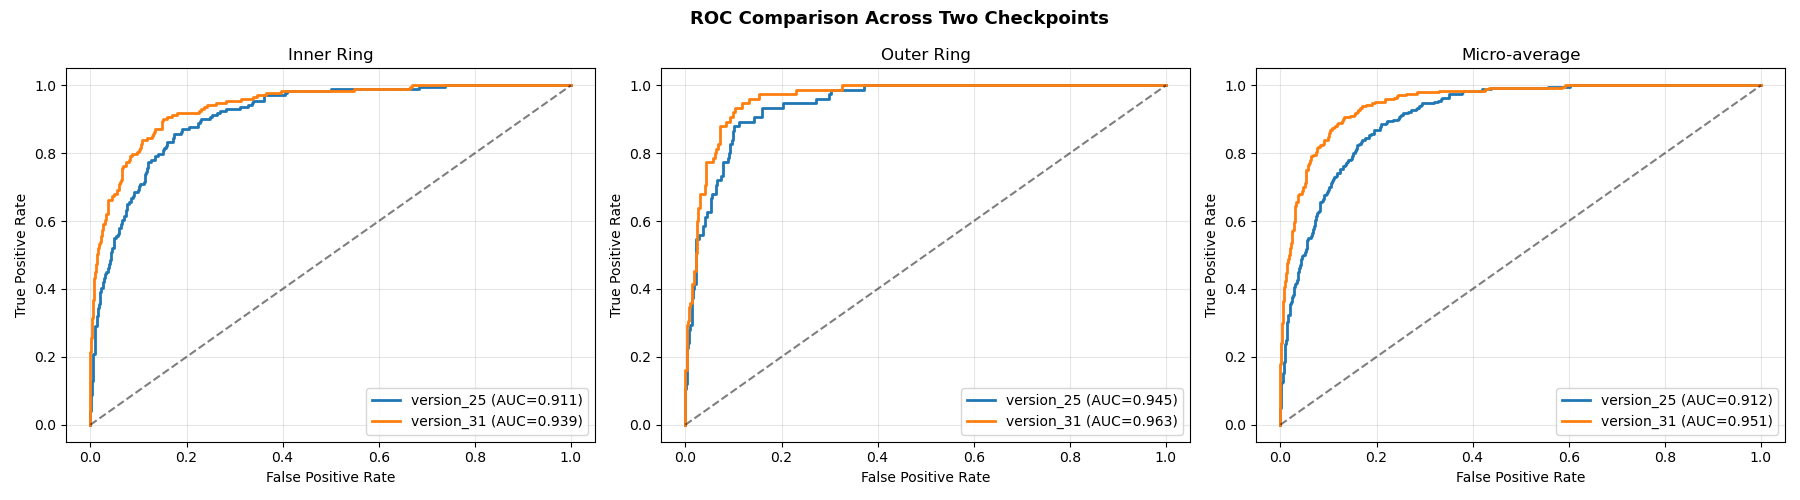

In [8]:
from sklearn.metrics import roc_curve, auc

def _collect_probs_labels(model_local, dataloader, use_tta=True, n_rotations=4, flip=True):
    probs_list, labels_list = [], []

    with torch.no_grad():
        for batch in dataloader:
            x_batch, y_batch = model_local.batch_to_supervised_tuple(batch)
            x_batch = x_batch.to(model_local.device)

            if use_tta and hasattr(model_local, "predict_proba_tta"):
                p_batch = model_local.predict_proba_tta(x_batch, n_rotations=n_rotations, flip=flip)
            else:
                p_batch = model_local(x_batch)

            probs_list.append(p_batch.detach().cpu().numpy())
            labels_list.append(y_batch.detach().cpu().numpy())

    probs_arr = np.concatenate(probs_list, axis=0)
    labels_arr = np.concatenate(labels_list, axis=0).astype(int)
    return probs_arr, labels_arr


def plot_roc_compare_two_checkpoints(
    model_a,
    model_b,
    dataloader_a,
    dataloader_b,
    name_a="Checkpoint A",
    name_b="Checkpoint B",
    use_tta=True,
    n_rotations=4,
    flip=True,
):
    probs_a, labels_a = _collect_probs_labels(model_a, dataloader_a, use_tta=use_tta, n_rotations=n_rotations, flip=flip)
    probs_b, labels_b = _collect_probs_labels(model_b, dataloader_b, use_tta=use_tta, n_rotations=n_rotations, flip=flip)

    if not np.array_equal(labels_a, labels_b):
        raise ValueError("Label mismatch between checkpoint evaluations. Use the same dataloader/order.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    label_names = ["Inner Ring", "Outer Ring"]

    for i, label_name in enumerate(label_names):
        fpr_a, tpr_a, _ = roc_curve(labels_a[:, i], probs_a[:, i])
        fpr_b, tpr_b, _ = roc_curve(labels_b[:, i], probs_b[:, i])
        auc_a = auc(fpr_a, tpr_a)
        auc_b = auc(fpr_b, tpr_b)

        axes[i].plot(fpr_a, tpr_a, lw=2, label=f"{name_a} (AUC={auc_a:.3f})")
        axes[i].plot(fpr_b, tpr_b, lw=2, label=f"{name_b} (AUC={auc_b:.3f})")
        axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
        axes[i].set_title(label_name)
        axes[i].set_xlabel("False Positive Rate")
        axes[i].set_ylabel("True Positive Rate")
        axes[i].grid(alpha=0.3)
        axes[i].legend()

    fpr_micro_a, tpr_micro_a, _ = roc_curve(labels_a.ravel(), probs_a.ravel())
    fpr_micro_b, tpr_micro_b, _ = roc_curve(labels_b.ravel(), probs_b.ravel())
    auc_micro_a = auc(fpr_micro_a, tpr_micro_a)
    auc_micro_b = auc(fpr_micro_b, tpr_micro_b)

    axes[2].plot(fpr_micro_a, tpr_micro_a, lw=2, label=f"{name_a} (AUC={auc_micro_a:.3f})")
    axes[2].plot(fpr_micro_b, tpr_micro_b, lw=2, label=f"{name_b} (AUC={auc_micro_b:.3f})")
    axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[2].set_title("Micro-average")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    fig.suptitle("ROC Comparison Across Two Checkpoints", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        "probs_a": probs_a,
        "probs_b": probs_b,
        "labels": labels_a,
        "auc_inner_a": auc(roc_curve(labels_a[:, 0], probs_a[:, 0])[0], roc_curve(labels_a[:, 0], probs_a[:, 0])[1]),
        "auc_inner_b": auc(roc_curve(labels_b[:, 0], probs_b[:, 0])[0], roc_curve(labels_b[:, 0], probs_b[:, 0])[1]),
        "auc_outer_a": auc(roc_curve(labels_a[:, 1], probs_a[:, 1])[0], roc_curve(labels_a[:, 1], probs_a[:, 1])[1]),
        "auc_outer_b": auc(roc_curve(labels_b[:, 1], probs_b[:, 1])[0], roc_curve(labels_b[:, 1], probs_b[:, 1])[1]),
        "auc_micro_a": auc_micro_a,
        "auc_micro_b": auc_micro_b,
    }


# Example usage:
results = plot_roc_compare_two_checkpoints(
    model_a=model_a,
    model_b=model_b,
    dataloader_a=datamodule_a.test_dataloader(),
    dataloader_b=datamodule_b.test_dataloader(),
    name_a=name_a,
    name_b=name_b,
    use_tta=True,
)

version_25 thresholds -> inner: 0.590, outer: 0.730
version_31 thresholds -> inner: 0.530, outer: 0.590


C:\Users\Francisco-PC\AppData\Local\Temp\ipykernel_3476\1488925224.py:7: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  pct = np.divide(cm * 100.0, row_sum, where=row_sum != 0)
C:\Users\Francisco-PC\AppData\Local\Temp\ipykernel_3476\1488925224.py:7: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  pct = np.divide(cm * 100.0, row_sum, where=row_sum != 0)
C:\Users\Francisco-PC\AppData\Local\Temp\ipykernel_3476\1488925224.py:7: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  pct = np.divide(cm * 100.0, row_sum, where=row_sum != 0)
C:\Users\Francisco-PC\AppData\Local\Temp\ipykernel_3476\1488925224.py:7: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  pct = np.divide(cm * 100.0, row_sum, where=row_sum != 0)
C:\Users

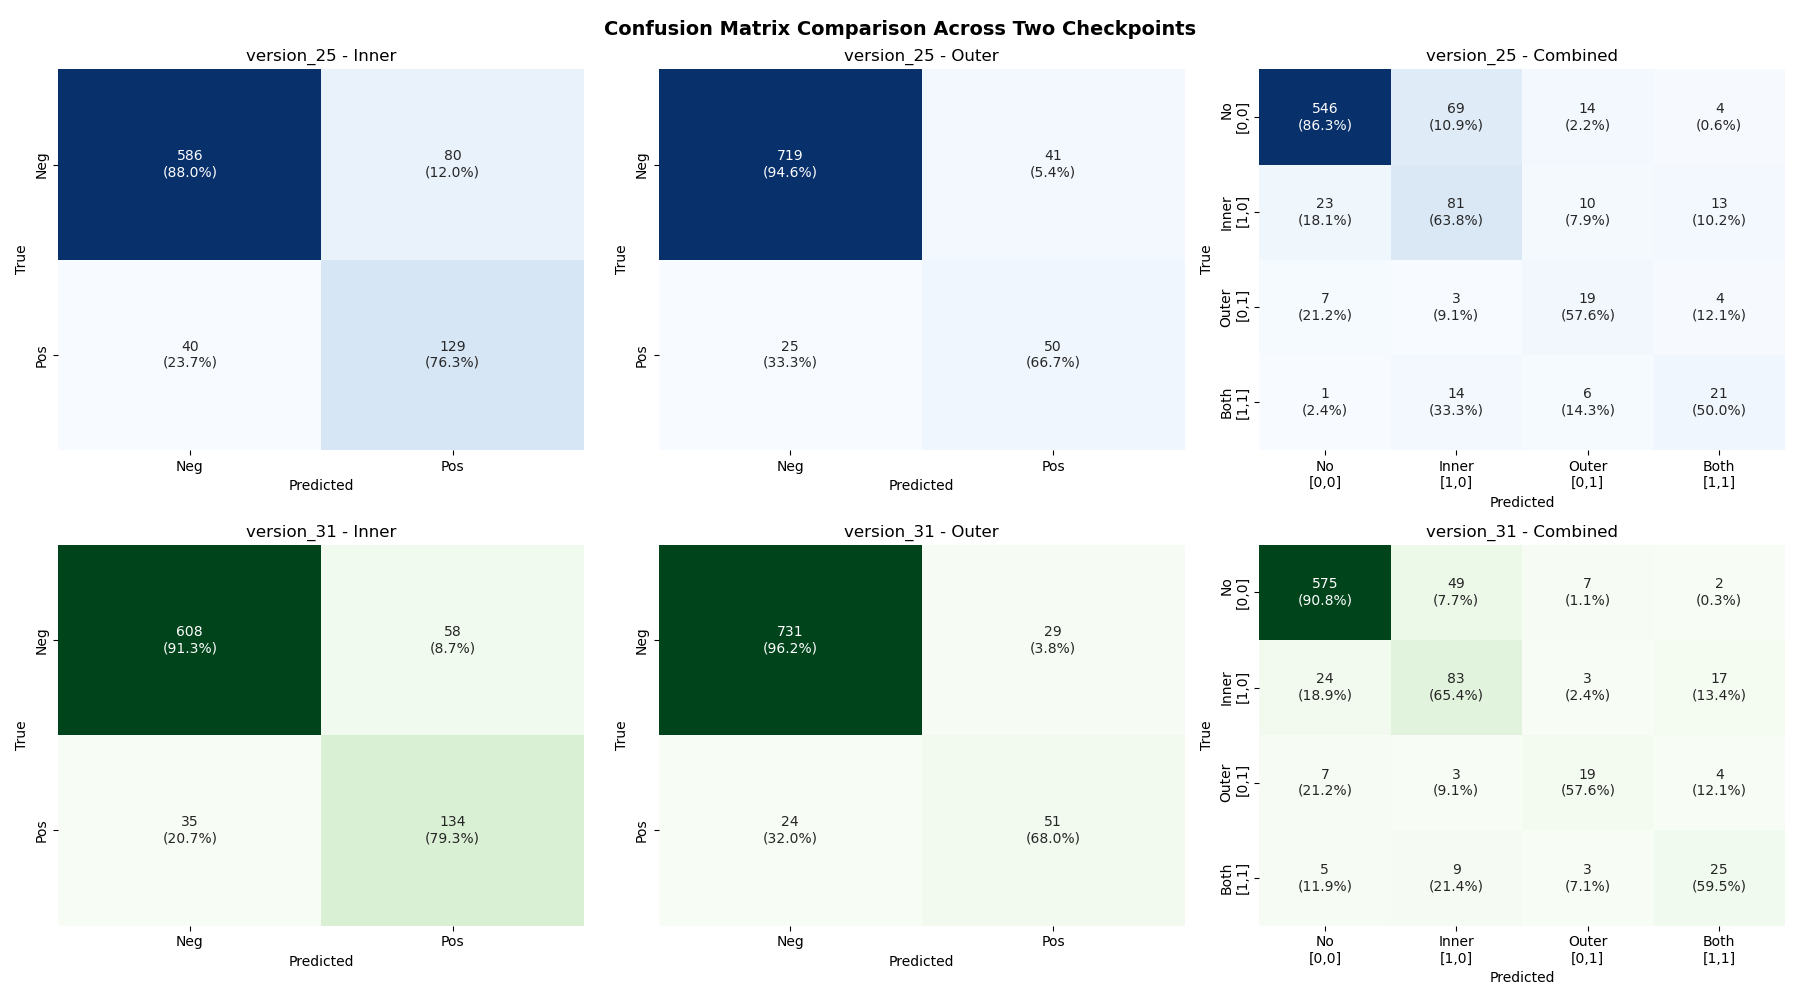

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def _annot_with_row_pct(cm):
    with np.errstate(divide="ignore", invalid="ignore"):
        row_sum = cm.sum(axis=1, keepdims=True)
        pct = np.divide(cm * 100.0, row_sum, where=row_sum != 0)
        pct = np.nan_to_num(pct)
    return np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(r_c, r_p)] for r_c, r_p in zip(cm, pct)])

def _annot_signed(cm):
    return np.array([[f"{int(v):+d}" for v in row] for row in cm])

def compare_confusion_matrices_two_checkpoints(
    model_a,
    model_b,
    dataloader_a,
    dataloader_b,
    name_a="Checkpoint A",
    name_b="Checkpoint B",
    use_tta=True,
    n_rotations=4,
    flip=True,
):
    """
    Compare confusion matrices (Inner, Outer, Combined 4-class) for two checkpoints,
    and plot matrix differences (name_b - name_a).
    """
    # Collect predictions
    probs_a, labels_a = _collect_probs_labels(
        model_a, dataloader_a, use_tta=use_tta, n_rotations=n_rotations, flip=flip
    )
    probs_b, labels_b = _collect_probs_labels(
        model_b, dataloader_b, use_tta=use_tta, n_rotations=n_rotations, flip=flip
    )

    if not np.array_equal(labels_a, labels_b):
        raise ValueError("Label mismatch between evaluations. Use same dataloader/order.")

    labels = labels_a.astype(int)

    # Get thresholds from models (fallback to 0.5 if missing)
    if hasattr(model_a, "inner_ring_threshold") and hasattr(model_a, "outer_ring_threshold"):
        thresholds_a = (model_a.inner_ring_threshold, model_a.outer_ring_threshold)
        print(f"{name_a} thresholds -> inner: {thresholds_a[0]:.3f}, outer: {thresholds_a[1]:.3f}")
    else:
        thresholds_a = (0.5, 0.5)
        print(f"{name_a} thresholds missing, using defaults -> inner: {thresholds_a[0]:.3f}, outer: {thresholds_a[1]:.3f}")

    if hasattr(model_b, "inner_ring_threshold") and hasattr(model_b, "outer_ring_threshold"):
        thresholds_b = (model_b.inner_ring_threshold, model_b.outer_ring_threshold)
        print(f"{name_b} thresholds -> inner: {thresholds_b[0]:.3f}, outer: {thresholds_b[1]:.3f}")
    else:
        thresholds_b = (0.5, 0.5)
        print(f"{name_b} thresholds missing, using defaults -> inner: {thresholds_b[0]:.3f}, outer: {thresholds_b[1]:.3f}")

    # Thresholding
    preds_a = np.zeros_like(probs_a, dtype=int)
    preds_b = np.zeros_like(probs_b, dtype=int)

    preds_a[:, 0] = (probs_a[:, 0] > thresholds_a[0]).astype(int)
    preds_a[:, 1] = (probs_a[:, 1] > thresholds_a[1]).astype(int)

    preds_b[:, 0] = (probs_b[:, 0] > thresholds_b[0]).astype(int)
    preds_b[:, 1] = (probs_b[:, 1] > thresholds_b[1]).astype(int)

    def _combo_map(arr_2col):
        # mapping: 00->0, 10->1, 01->2, 11->3
        key = arr_2col[:, 0] * 10 + arr_2col[:, 1]
        mapping = {0: 0, 10: 1, 1: 2, 11: 3}
        return np.array([mapping[k] for k in key])

    # Build confusion matrices
    cm_a_inner = confusion_matrix(labels[:, 0], preds_a[:, 0])
    cm_a_outer = confusion_matrix(labels[:, 1], preds_a[:, 1])
    cm_b_inner = confusion_matrix(labels[:, 0], preds_b[:, 0])
    cm_b_outer = confusion_matrix(labels[:, 1], preds_b[:, 1])

    y_combo = _combo_map(labels)
    pa_combo = _combo_map(preds_a)
    pb_combo = _combo_map(preds_b)

    cm_a_combo = confusion_matrix(y_combo, pa_combo, labels=[0, 1, 2, 3])
    cm_b_combo = confusion_matrix(y_combo, pb_combo, labels=[0, 1, 2, 3])

    diff_inner = cm_b_inner - cm_a_inner
    diff_outer = cm_b_outer - cm_a_outer
    diff_combo = cm_b_combo - cm_a_combo

    # Plot 1: absolute confusion matrices
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    sns.heatmap(
        cm_a_inner, annot=_annot_with_row_pct(cm_a_inner), fmt="", cmap="Blues", cbar=False, ax=axes[0, 0],
        xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"]
    )
    axes[0, 0].set_title(f"{name_a} - Inner")
    axes[0, 0].set_xlabel("Predicted")
    axes[0, 0].set_ylabel("True")

    sns.heatmap(
        cm_a_outer, annot=_annot_with_row_pct(cm_a_outer), fmt="", cmap="Blues", cbar=False, ax=axes[0, 1],
        xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"]
    )
    axes[0, 1].set_title(f"{name_a} - Outer")
    axes[0, 1].set_xlabel("Predicted")
    axes[0, 1].set_ylabel("True")

    combo_labels = ["No\n[0,0]", "Inner\n[1,0]", "Outer\n[0,1]", "Both\n[1,1]"]
    sns.heatmap(
        cm_a_combo, annot=_annot_with_row_pct(cm_a_combo), fmt="", cmap="Blues", cbar=False, ax=axes[0, 2],
        xticklabels=combo_labels, yticklabels=combo_labels
    )
    axes[0, 2].set_title(f"{name_a} - Combined")
    axes[0, 2].set_xlabel("Predicted")
    axes[0, 2].set_ylabel("True")

    sns.heatmap(
        cm_b_inner, annot=_annot_with_row_pct(cm_b_inner), fmt="", cmap="Greens", cbar=False, ax=axes[1, 0],
        xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"]
    )
    axes[1, 0].set_title(f"{name_b} - Inner")
    axes[1, 0].set_xlabel("Predicted")
    axes[1, 0].set_ylabel("True")

    sns.heatmap(
        cm_b_outer, annot=_annot_with_row_pct(cm_b_outer), fmt="", cmap="Greens", cbar=False, ax=axes[1, 1],
        xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"]
    )
    axes[1, 1].set_title(f"{name_b} - Outer")
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("True")

    sns.heatmap(
        cm_b_combo, annot=_annot_with_row_pct(cm_b_combo), fmt="", cmap="Greens", cbar=False, ax=axes[1, 2],
        xticklabels=combo_labels, yticklabels=combo_labels
    )
    axes[1, 2].set_title(f"{name_b} - Combined")
    axes[1, 2].set_xlabel("Predicted")
    axes[1, 2].set_ylabel("True")

    fig.suptitle("Confusion Matrix Comparison Across Two Checkpoints", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Plot 2: difference heatmaps (name_b - name_a)
    return {
        "labels": labels,
        "preds_a": preds_a,
        "preds_b": preds_b,
        "cm_a_inner": cm_a_inner,
        "cm_a_outer": cm_a_outer,
        "cm_a_combo": cm_a_combo,
        "cm_b_inner": cm_b_inner,
        "cm_b_outer": cm_b_outer,
        "cm_b_combo": cm_b_combo, 
        "diff_inner": diff_inner,
        "diff_outer": diff_outer,
        "diff_combo": diff_combo,
        "thresholds_a": thresholds_a,
        "thresholds_b": thresholds_b,
    }

def plot_confusion_matrix_differences(diff_inner, diff_outer, diff_combo, name_a, name_b, title="Confusion Matrix Difference (B - A)"):
    fig_diff, axes_diff = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(
        diff_inner, annot=_annot_signed(diff_inner), fmt="", cmap="RdBu_r", center=0, cbar=True, ax=axes_diff[0],
        xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"]
    )
    axes_diff[0].set_title("Diff - Inner (B - A)")
    axes_diff[0].set_xlabel("Predicted")
    axes_diff[0].set_ylabel("True")

    sns.heatmap(
        diff_outer, annot=_annot_signed(diff_outer), fmt="", cmap="RdBu_r", center=0, cbar=True, ax=axes_diff[1],
        xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"]
    )
    axes_diff[1].set_title("Diff - Outer (B - A)")
    axes_diff[1].set_xlabel("Predicted")
    axes_diff[1].set_ylabel("True")

    combo_labels = ["No\n[0,0]", "Inner\n[1,0]", "Outer\n[0,1]", "Both\n[1,1]"]
    sns.heatmap(
        diff_combo, annot=_annot_signed(diff_combo), fmt="", cmap="RdBu_r", center=0, cbar=True, ax=axes_diff[2],
        xticklabels=combo_labels, yticklabels=combo_labels
    )
    axes_diff[2].set_title("Diff - Combined (B - A)")
    axes_diff[2].set_xlabel("Predicted")
    axes_diff[2].set_ylabel("True")

    fig_diff.suptitle(f"Confusion Matrix Difference: {name_b} - {name_a}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Example:
cm_results = compare_confusion_matrices_two_checkpoints(
    model_a=model_a,
    model_b=model_b,
    dataloader_a=datamodule_a.test_dataloader(),
    dataloader_b=datamodule_b.test_dataloader(),
    name_a=name_a,
    name_b=name_b,
    use_tta=True,
)

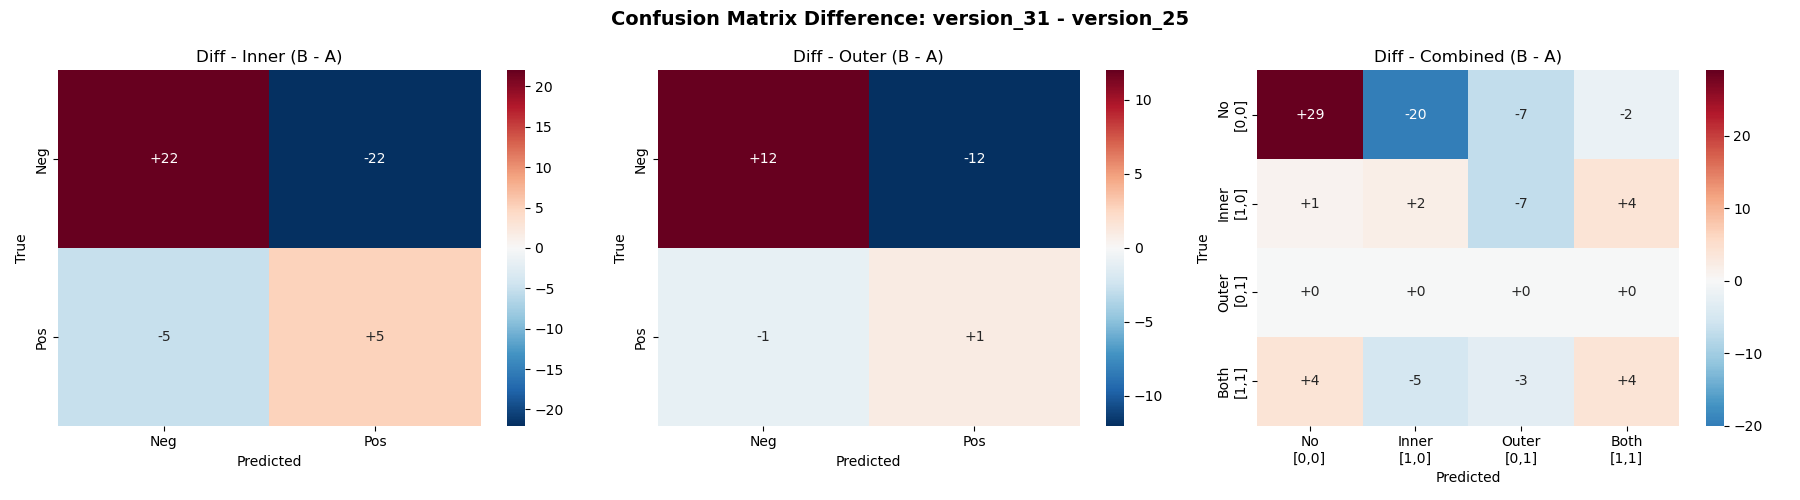

In [10]:
#Use cm_results to plot the confusion matrix diff
plot_confusion_matrix_differences(
    diff_inner=cm_results["diff_inner"],
    diff_outer=cm_results["diff_outer"],
    diff_combo=cm_results["diff_combo"],
    name_a=name_a,
    name_b=name_b,
)

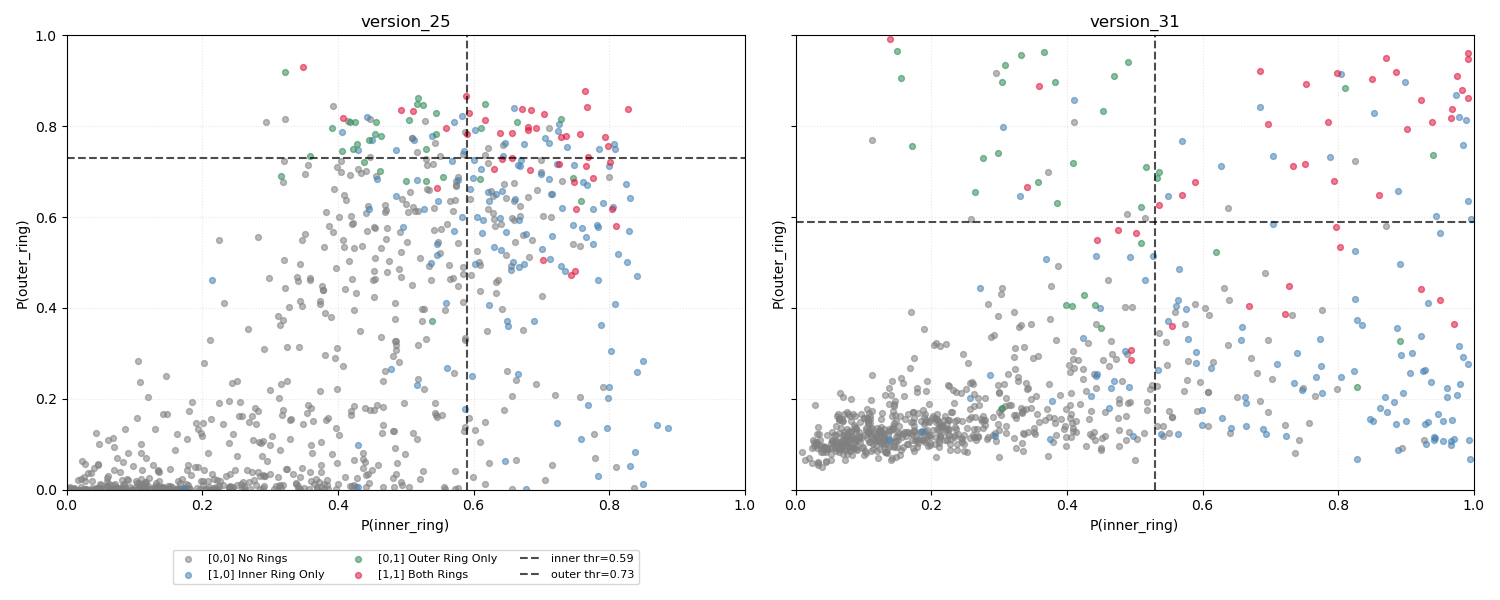

In [11]:
def plot_compare_interactive_probability_scatter(
    model_a,
    model_b,
    dataloader_a,
    dataloader_b,
    name_a="Checkpoint A",
    name_b="Checkpoint B",
    use_tta=True,
    n_rotations=4,
    flip=True,
):
    """
    Compare two checkpoints with side-by-side 2D probability scatterplots.
    Points are colored by true multilabel class.
    Each plot shows its own threshold lines (inner/outer).
    Clicking a point highlights the same sample in both plots.
    """
    model_a.eval()
    model_b.eval()

    all_probs_a, all_probs_b, all_labels = [], [], []

    with torch.no_grad():
        for batch_a, batch_b in zip(dataloader_a, dataloader_b):
            x_a, y_a = model_a.batch_to_supervised_tuple(batch_a)
            x_b, y_b = model_b.batch_to_supervised_tuple(batch_b)

            xa = x_a.to(model_a.device)
            xb = x_b.to(model_b.device)

            if use_tta and hasattr(model_a, "predict_proba_tta"):
                pa = model_a.predict_proba_tta(xa, n_rotations=n_rotations, flip=flip)
            else:
                pa = model_a(xa)

            if use_tta and hasattr(model_b, "predict_proba_tta"):
                pb = model_b.predict_proba_tta(xb, n_rotations=n_rotations, flip=flip)
            else:
                pb = model_b(xb)

            all_probs_a.append(pa.detach().cpu().numpy())
            all_probs_b.append(pb.detach().cpu().numpy())
            all_labels.append(y_a.detach().cpu().numpy())

    probs_a = np.concatenate(all_probs_a, axis=0)
    probs_b = np.concatenate(all_probs_b, axis=0)
    labels = np.concatenate(all_labels, axis=0).astype(int)

    preds_a = np.zeros_like(probs_a, dtype=int)
    preds_b = np.zeros_like(probs_b, dtype=int)

    #Get thresholds from models as (inner, outer) tuples
    thresholds_a = (model_a.inner_ring_threshold, model_a.outer_ring_threshold)
    thresholds_b = (model_b.inner_ring_threshold, model_b.outer_ring_threshold)

    preds_a[:, 0] = (probs_a[:, 0] > thresholds_a[0]).astype(int)
    preds_a[:, 1] = (probs_a[:, 1] > thresholds_a[1]).astype(int)

    preds_b[:, 0] = (probs_b[:, 0] > thresholds_b[0]).astype(int)
    preds_b[:, 1] = (probs_b[:, 1] > thresholds_b[1]).astype(int)

    LABEL_COLORS = {
        (0, 0): "gray",
        (1, 0): "steelblue",
        (0, 1): "seagreen",
        (1, 1): "crimson",
    }
    LABEL_NAMES = {
        (0, 0): "No Rings",
        (1, 0): "Inner Ring Only",
        (0, 1): "Outer Ring Only",
        (1, 1): "Both Rings",
    }

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
    ax_a, ax_b = axes

    scatter_map_a = {}
    scatter_map_b = {}

    for combo, color in LABEL_COLORS.items():
        idx = np.where((labels[:, 0] == combo[0]) & (labels[:, 1] == combo[1]))[0]
        if len(idx) == 0:
            continue

        sa = ax_a.scatter(
            probs_a[idx, 0], probs_a[idx, 1],
            c=color, s=18, alpha=0.55, picker=6,
            label=f"[{combo[0]},{combo[1]}] {LABEL_NAMES[combo]}"
        )
        sb = ax_b.scatter(
            probs_b[idx, 0], probs_b[idx, 1],
            c=color, s=18, alpha=0.55, picker=6
        )
        scatter_map_a[sa] = idx
        scatter_map_b[sb] = idx

    # Threshold lines per model
    ax_a.axvline(thresholds_a[0], linestyle="--", color="black", alpha=0.7, label=f"inner thr={thresholds_a[0]:.2f}")
    ax_a.axhline(thresholds_a[1], linestyle="--", color="black", alpha=0.7, label=f"outer thr={thresholds_a[1]:.2f}")

    ax_b.axvline(thresholds_b[0], linestyle="--", color="black", alpha=0.7, label=f"inner thr={thresholds_b[0]:.2f}")
    ax_b.axhline(thresholds_b[1], linestyle="--", color="black", alpha=0.7, label=f"outer thr={thresholds_b[1]:.2f}")

    ax_a.set_title(name_a)
    ax_b.set_title(name_b)

    for ax in axes:
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("P(inner_ring)")
        ax.set_ylabel("P(outer_ring)")
        ax.grid(True, linestyle=":", alpha=0.3)

    ax_a.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8, framealpha=0.8)

    hi_a, = ax_a.plot([], [], "o", ms=12, mfc="none", mec="gold", mew=2, zorder=5)
    hi_b, = ax_b.plot([], [], "o", ms=12, mfc="none", mec="gold", mew=2, zorder=5)

    def _set_selection(i):
        hi_a.set_data([probs_a[i, 0]], [probs_a[i, 1]])
        hi_b.set_data([probs_b[i, 0]], [probs_b[i, 1]])

        gt = labels[i]
        pa = probs_a[i]
        pb = probs_b[i]
        pra = preds_a[i]
        prb = preds_b[i]

        fig.suptitle(
            f"Sample #{i} | GT=[{gt[0]},{gt[1]}] {LABEL_NAMES[tuple(gt)]} | "
            f"{name_a}: p=({pa[0]:.3f},{pa[1]:.3f}) pred=[{pra[0]},{pra[1]}] | "
            f"{name_b}: p=({pb[0]:.3f},{pb[1]:.3f}) pred=[{prb[0]},{prb[1]}]",
            fontsize=10
        )
        fig.canvas.draw_idle()

    def on_pick(event):
        artist = event.artist

        if artist in scatter_map_a:
            candidates = scatter_map_a[artist][event.ind]
            p_ref = probs_a
        elif artist in scatter_map_b:
            candidates = scatter_map_b[artist][event.ind]
            p_ref = probs_b
        else:
            return

        if hasattr(event, "mouseevent") and event.mouseevent is not None:
            mx, my = event.mouseevent.xdata, event.mouseevent.ydata
            if mx is not None and my is not None:
                d = (p_ref[candidates, 0] - mx) ** 2 + (p_ref[candidates, 1] - my) ** 2
                idx = int(candidates[np.argmin(d)])
            else:
                idx = int(candidates[0])
        else:
            idx = int(candidates[0])

        _set_selection(idx)

    fig.canvas.mpl_connect("pick_event", on_pick)
    plt.tight_layout()
    plt.show()

    return {
        "probs_a": probs_a,
        "probs_b": probs_b,
        "labels": labels,
        "preds_a": preds_a,
        "preds_b": preds_b,
        "thresholds_a": thresholds_a,
        "thresholds_b": thresholds_b,
    }

# Example:
compare_results = plot_compare_interactive_probability_scatter(
    model_a=model_a,
    model_b=model_b,
    dataloader_a=datamodule_a.test_dataloader(),
    dataloader_b=datamodule_b.test_dataloader(),
    name_a=name_a,
    name_b=name_b,
    use_tta=True,
)

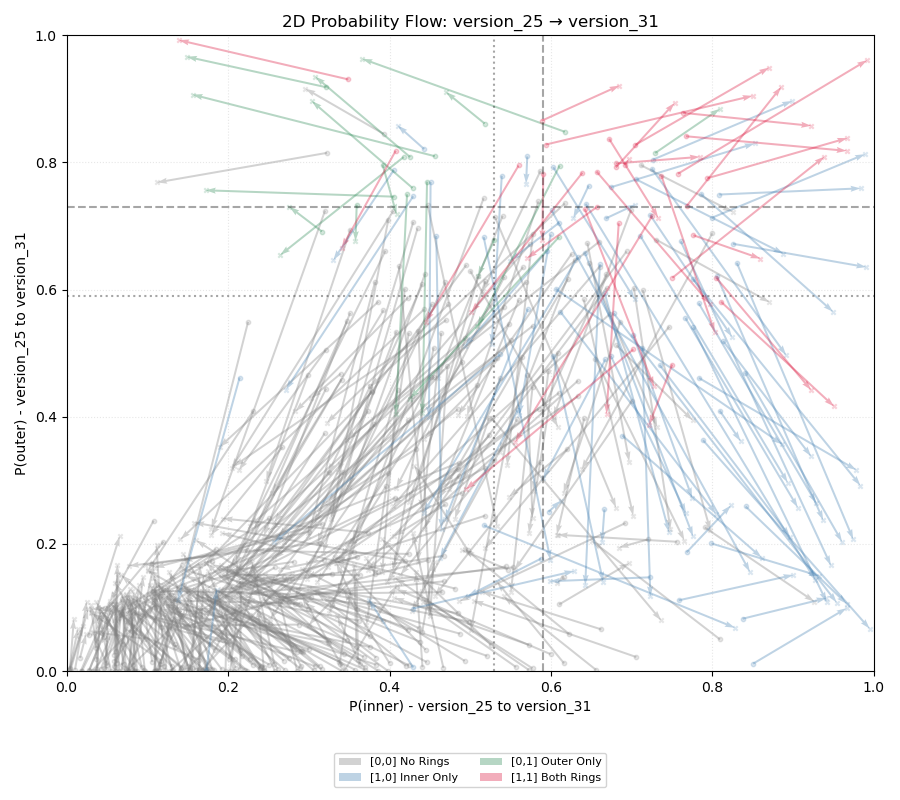

In [12]:
def plot_probability_flow_between_models(
    compare_results,
    name_a="Model A",
    name_b="Model B",
    max_points=500,
    arrow_alpha=0.35,
    arrow_width=0.0025,
):
    probs_a = compare_results["probs_a"]
    probs_b = compare_results["probs_b"]
    labels = compare_results["labels"]
    thr_a = compare_results.get("thresholds_a", (0.5, 0.5))
    thr_b = compare_results.get("thresholds_b", (0.5, 0.5))

    n = probs_a.shape[0]
    idx = np.arange(n)
    if max_points is not None and n > max_points:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(idx, size=max_points, replace=False)

    pa = probs_a[idx]
    pb = probs_b[idx]
    y = labels[idx]

    dx = pb[:, 0] - pa[:, 0]
    dy = pb[:, 1] - pa[:, 1]

    class_colors = {
        (0, 0): "gray",
        (1, 0): "steelblue",
        (0, 1): "seagreen",
        (1, 1): "crimson",
    }
    class_names = {
        (0, 0): "No Rings",
        (1, 0): "Inner Only",
        (0, 1): "Outer Only",
        (1, 1): "Both Rings",
    }

    fig, ax = plt.subplots(figsize=(9, 8))

    # Threshold guides
    ax.axvline(thr_a[0], color="black", linestyle="--", alpha=0.35)
    ax.axhline(thr_a[1], color="black", linestyle="--", alpha=0.35)
    ax.axvline(thr_b[0], color="black", linestyle=":", alpha=0.35)
    ax.axhline(thr_b[1], color="black", linestyle=":", alpha=0.35)

    # Flow arrows grouped by true class
    for cls, color in class_colors.items():
        m = (y[:, 0] == cls[0]) & (y[:, 1] == cls[1])
        if not np.any(m):
            continue

        ax.quiver(
            pa[m, 0], pa[m, 1],
            dx[m], dy[m],
            angles="xy",
            scale_units="xy",
            scale=1,
            color=color,
            alpha=arrow_alpha,
            width=arrow_width,
            label=f"[{cls[0]},{cls[1]}] {class_names[cls]}",
        )

        # Start and end points (light)
        ax.scatter(pa[m, 0], pa[m, 1], s=10, c=color, alpha=0.20, marker="o")
        ax.scatter(pb[m, 0], pb[m, 1], s=10, c=color, alpha=0.20, marker="x")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(f"P(inner) - {name_a} to {name_b}")
    ax.set_ylabel(f"P(outer) - {name_a} to {name_b}")
    ax.set_title(f"2D Probability Flow: {name_a} → {name_b}")
    ax.grid(True, linestyle=":", alpha=0.3)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8, framealpha=0.85)

    plt.tight_layout()
    plt.show()


# Plot using existing notebook variables
plot_probability_flow_between_models(
    compare_results=compare_results,
    name_a=name_a,
    name_b=name_b,
    max_points=500,  # set None to draw all points
)

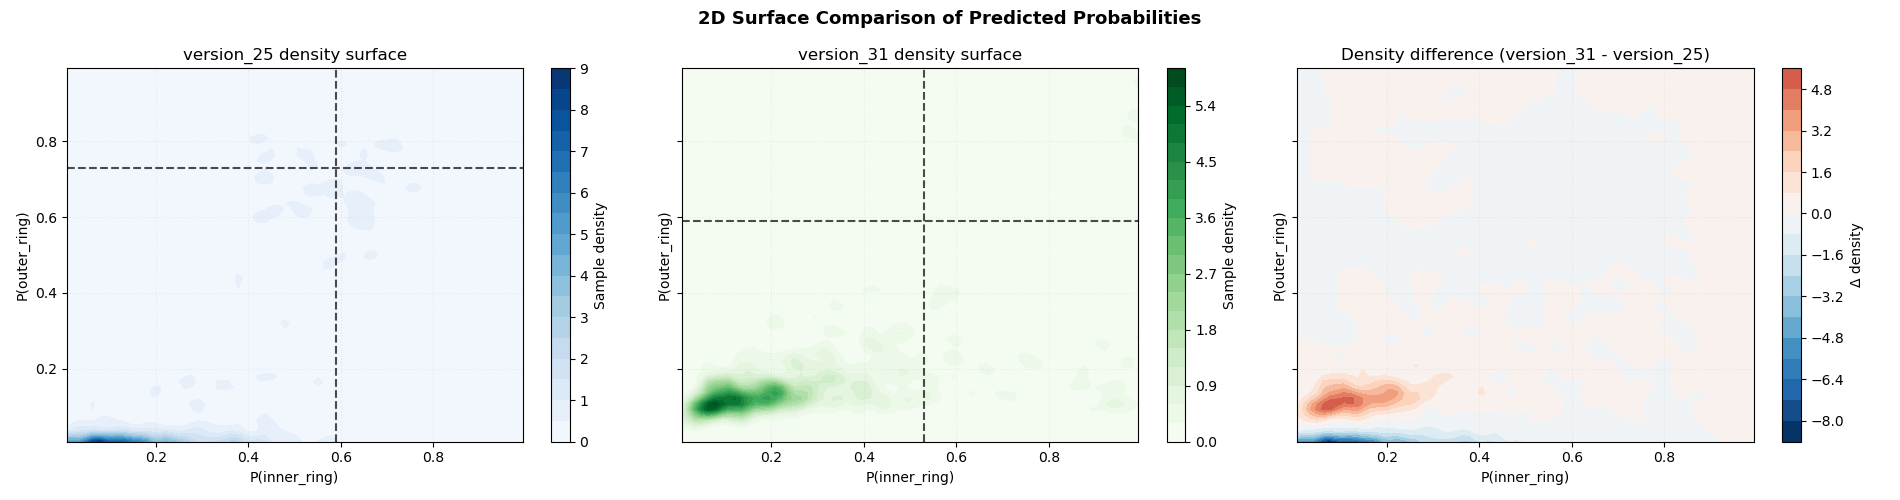

In [13]:
def plot_compare_probability_surface(
    model_a,
    model_b,
    dataloader_a,
    dataloader_b,
    name_a="Checkpoint A",
    name_b="Checkpoint B",
    use_tta=True,
    n_rotations=4,
    flip=True,
    bins=60,
    smooth_sigma=1.2,
    show_diff=True,
):
    """
    2D surface-style comparison of probability distributions from two checkpoints.
    Uses smoothed 2D histograms over (P(inner), P(outer)).
    """
    probs_a, labels_a = _collect_probs_labels(
        model_a, dataloader_a, use_tta=use_tta, n_rotations=n_rotations, flip=flip
    )
    probs_b, labels_b = _collect_probs_labels(
        model_b, dataloader_b, use_tta=use_tta, n_rotations=n_rotations, flip=flip
    )

    if not np.array_equal(labels_a, labels_b):
        raise ValueError("Label mismatch between checkpoint evaluations. Use same dataloader/order.")

    x_edges = np.linspace(0.0, 1.0, bins + 1)
    y_edges = np.linspace(0.0, 1.0, bins + 1)

    h_a, _, _ = np.histogram2d(probs_a[:, 0], probs_a[:, 1], bins=[x_edges, y_edges])
    h_b, _, _ = np.histogram2d(probs_b[:, 0], probs_b[:, 1], bins=[x_edges, y_edges])

    if smooth_sigma and smooth_sigma > 0:
        h_a = gaussian_filter(h_a, sigma=smooth_sigma)
        h_b = gaussian_filter(h_b, sigma=smooth_sigma)

    h_diff = h_b - h_a

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    X, Y = np.meshgrid(x_centers, y_centers, indexing="ij")

    if show_diff:
        fig, axes = plt.subplots(1, 3, figsize=(19, 5), sharex=True, sharey=True)
        ax_a, ax_b, ax_d = axes
    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
        ax_a, ax_b = axes

    c1 = ax_a.contourf(X, Y, h_a, levels=20, cmap="Blues")
    ax_a.axvline(model_a.inner_ring_threshold, linestyle="--", color="black", alpha=0.7)
    ax_a.axhline(model_a.outer_ring_threshold, linestyle="--", color="black", alpha=0.7)
    ax_a.set_title(f"{name_a} density surface")
    ax_a.set_xlabel("P(inner_ring)")
    ax_a.set_ylabel("P(outer_ring)")
    ax_a.grid(alpha=0.2, linestyle=":")
    fig.colorbar(c1, ax=ax_a, label="Sample density")

    c2 = ax_b.contourf(X, Y, h_b, levels=20, cmap="Greens")
    ax_b.axvline(model_b.inner_ring_threshold, linestyle="--", color="black", alpha=0.7)
    ax_b.axhline(model_b.outer_ring_threshold, linestyle="--", color="black", alpha=0.7)
    ax_b.set_title(f"{name_b} density surface")
    ax_b.set_xlabel("P(inner_ring)")
    ax_b.set_ylabel("P(outer_ring)")
    ax_b.grid(alpha=0.2, linestyle=":")
    fig.colorbar(c2, ax=ax_b, label="Sample density")

    if show_diff:
        vmax = np.max(np.abs(h_diff)) if np.max(np.abs(h_diff)) > 0 else 1.0
        c3 = ax_d.contourf(X, Y, h_diff, levels=20, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax_d.set_title(f"Density difference ({name_b} - {name_a})")
        ax_d.set_xlabel("P(inner_ring)")
        ax_d.set_ylabel("P(outer_ring)")
        ax_d.grid(alpha=0.2, linestyle=":")
        fig.colorbar(c3, ax=ax_d, label="Δ density")

    fig.suptitle("2D Surface Comparison of Predicted Probabilities", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        "probs_a": probs_a,
        "probs_b": probs_b,
        "labels": labels_a,
        "surface_a": h_a,
        "surface_b": h_b,
        "surface_diff": h_diff,
        "x_edges": x_edges,
        "y_edges": y_edges,
    }


# Example:
surface_results = plot_compare_probability_surface(
    model_a=model_a,
    model_b=model_b,
    dataloader_a=datamodule_a.test_dataloader(),
    dataloader_b=datamodule_b.test_dataloader(),
    name_a=name_a,
    name_b=name_b,
    use_tta=True,
    bins=70,
    smooth_sigma=1.0,
    show_diff=True,
)

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def compare_numeric_metrics_table(compare_results, name_a="Model A", name_b="Model B", round_digits=4):
    labels = compare_results["labels"].astype(int)

    probs_a = compare_results["probs_a"]
    probs_b = compare_results["probs_b"]
    preds_a = compare_results["preds_a"].astype(int)
    preds_b = compare_results["preds_b"].astype(int)

    def _safe_auc(y_true, y_score):
        try:
            return roc_auc_score(y_true, y_score)
        except ValueError:
            return np.nan

    def _compute_metrics(probs, preds, y):
        out = {}

        # Exact-match / subset accuracy (both labels correct in a sample)
        out["subset_accuracy"] = np.mean(np.all(preds == y, axis=1))

        # Label-wise metrics
        for i, label_name in enumerate(["inner", "outer"]):
            out[f"{label_name}_accuracy"] = np.mean(preds[:, i] == y[:, i])
            out[f"{label_name}_precision"] = precision_score(y[:, i], preds[:, i], zero_division=0)
            out[f"{label_name}_recall"] = recall_score(y[:, i], preds[:, i], zero_division=0)
            out[f"{label_name}_f1"] = f1_score(y[:, i], preds[:, i], zero_division=0)
            out[f"{label_name}_auc"] = _safe_auc(y[:, i], probs[:, i])

        # Global multilabel metrics
        out["micro_precision"] = precision_score(y.ravel(), preds.ravel(), zero_division=0)
        out["micro_recall"] = recall_score(y.ravel(), preds.ravel(), zero_division=0)
        out["micro_f1"] = f1_score(y.ravel(), preds.ravel(), zero_division=0)
        out["macro_f1"] = f1_score(y, preds, average="macro", zero_division=0)
        out["micro_auc"] = _safe_auc(y.ravel(), probs.ravel())

        return out

    metrics_a = _compute_metrics(probs_a, preds_a, labels)
    metrics_b = _compute_metrics(probs_b, preds_b, labels)

    ordered_metrics = [
        "subset_accuracy",
        "inner_accuracy", "inner_precision", "inner_recall", "inner_f1", "inner_auc",
        "outer_accuracy", "outer_precision", "outer_recall", "outer_f1", "outer_auc",
        "micro_precision", "micro_recall", "micro_f1", "macro_f1", "micro_auc",
    ]

    table = pd.DataFrame({
        "metric": ordered_metrics,
        name_a: [metrics_a[m] for m in ordered_metrics],
        name_b: [metrics_b[m] for m in ordered_metrics],
    })
    table["delta_b_minus_a"] = table[name_b] - table[name_a]

    return table.round(round_digits)


# Example usage (uses existing notebook variables):
metrics_table = compare_numeric_metrics_table(compare_results, name_a=name_a, name_b=name_b)
metrics_table

,metric,version_25,version_31,delta_b_minus_a
0,subset_accuracy,0.7988,0.8407,0.0419
1,inner_accuracy,0.8563,0.8886,0.0323
2,inner_precision,0.6172,0.6979,0.0807
3,inner_recall,0.7633,0.7929,0.0296
4,inner_f1,0.6825,0.7424,0.0598
5,inner_auc,0.9115,0.9391,0.0277
6,outer_accuracy,0.9210,0.9365,0.0156
7,outer_precision,0.5495,0.6375,0.0880
8,outer_recall,0.6667,0.6800,0.0133
9,outer_f1,0.6024,0.6581,0.0557
